In [3]:
import pandas as pd
df = pd.read_csv('fraudTest.csv')
print(df.head())
print(df.shape)


   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2020-06-21 12:14:25  2291163933867244   
1           1   2020-06-21 12:14:33  3573030041201292   
2           2   2020-06-21 12:14:53  3598215285024754   
3           3   2020-06-21 12:15:15  3591919803438423   
4           4   2020-06-21 12:15:17  3526826139003047   

                               merchant        category    amt   first  \
0                 fraud_Kirlin and Sons   personal_care   2.86    Jeff   
1                  fraud_Sporer-Keebler   personal_care  29.84  Joanne   
2  fraud_Swaniawski, Nitzsche and Welch  health_fitness  41.28  Ashley   
3                     fraud_Haley Group        misc_pos  60.05   Brian   
4                 fraud_Johnston-Casper          travel   3.19  Nathan   

       last gender                       street  ...      lat      long  \
0   Elliott      M            351 Darlene Green  ...  33.9659  -80.9355   
1  Williams      F             3638 Marsh Union  ...  40.3207 

In [2]:
import os
print(os.getcwd())
print(os.listdir())


c:\Users\Adwaith Nambiar\OneDrive\Desktop\fraud detection
['fraud detection.ipynb', 'fraudTest.csv']


In [4]:
print(df.columns.tolist())


['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


In [5]:
print(df['is_fraud'].value_counts())
print(df['is_fraud'].value_counts(normalize=True) * 100)


is_fraud
0    553574
1      2145
Name: count, dtype: int64
is_fraud
0    99.614014
1     0.385986
Name: proportion, dtype: float64


In [6]:
print(df.isnull().sum())


Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


In [7]:
print(df['category'].value_counts())


category
gas_transport     56370
grocery_pos       52553
home              52345
shopping_pos      49791
kids_pets         48692
shopping_net      41779
entertainment     40104
personal_care     39327
food_dining       39268
health_fitness    36674
misc_pos          34574
misc_net          27367
grocery_net       19426
travel            17449
Name: count, dtype: int64


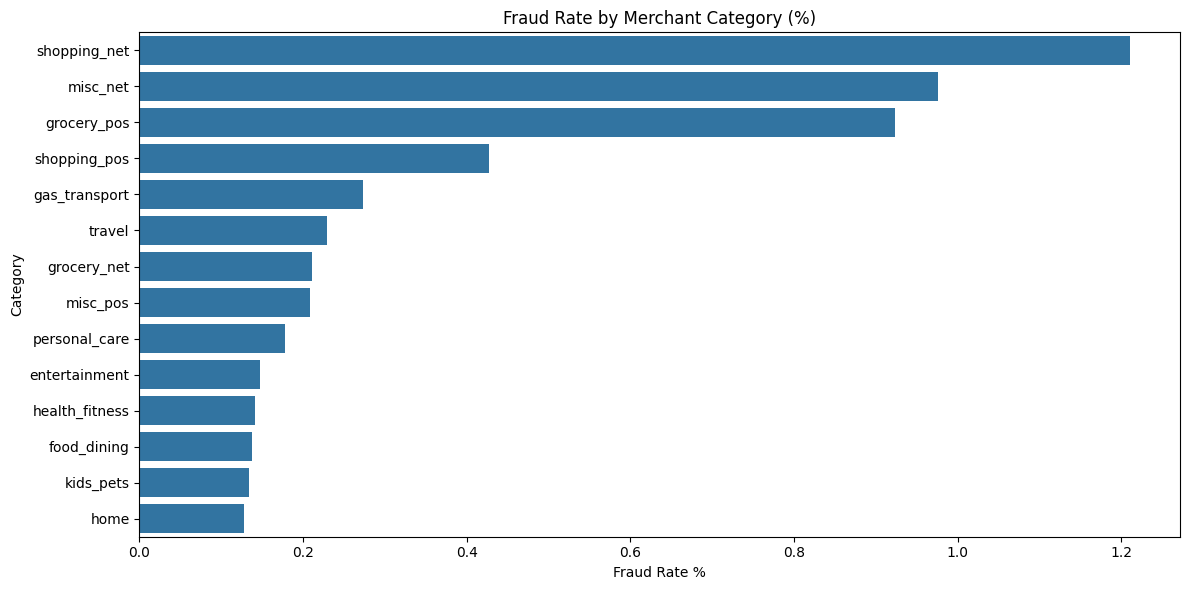

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fraud_by_category = df.groupby('category')['is_fraud'].mean() * 100
fraud_by_category = fraud_by_category.sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=fraud_by_category.values, y=fraud_by_category.index)
plt.title('Fraud Rate by Merchant Category (%)')
plt.xlabel('Fraud Rate %')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

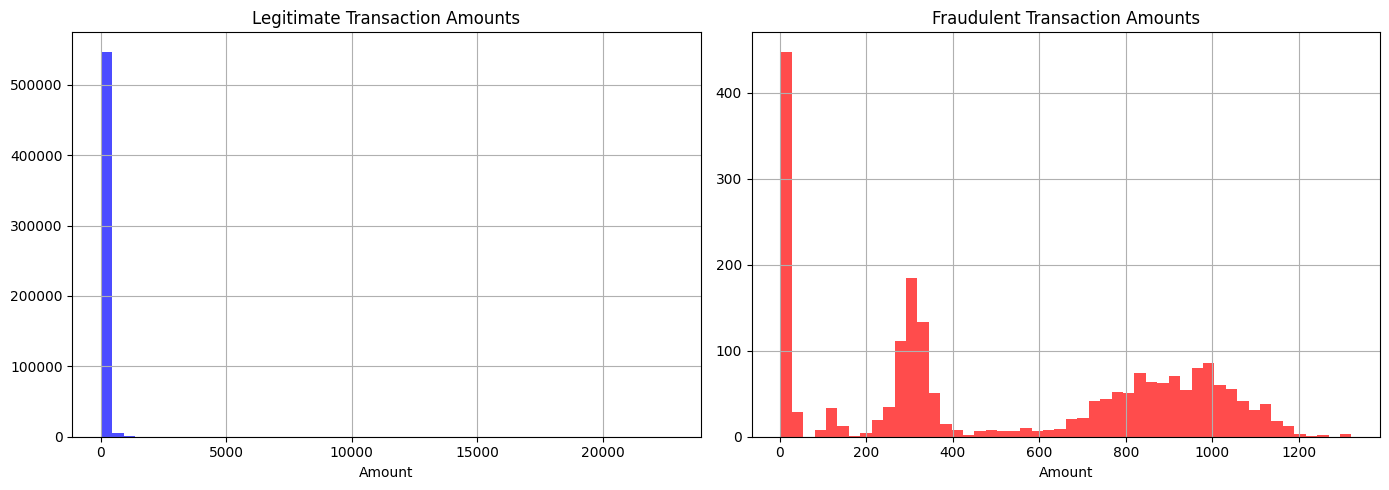

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

df[df['is_fraud']==0]['amt'].hist(bins=50, ax=ax1, color='blue', alpha=0.7)
ax1.set_title('Legitimate Transaction Amounts')
ax1.set_xlabel('Amount')

df[df['is_fraud']==1]['amt'].hist(bins=50, ax=ax2, color='red', alpha=0.7)
ax2.set_title('Fraudulent Transaction Amounts')
ax2.set_xlabel('Amount')

plt.tight_layout()
plt.show()


## Key Finding 4 — Transaction Amounts
Legitimate transactions cluster at low amounts.
Fraudulent transactions show wider distribution with multiple peaks
at small amounts and higher amounts (£300, £800-1000).
Fraudsters deliberately vary transaction amounts to avoid detection.
Transaction amount alone is insufficient to detect fraud.

In [10]:
print(df.groupby('gender')['is_fraud'].mean() * 100)

gender
F    0.381782
M    0.391097
Name: is_fraud, dtype: float64


## Key Finding 5 — Fraud by Gender
Male and female customers show virtually identical fraud rates
(0.38% vs 0.39%). Gender is not a meaningful predictor of fraud
and will likely be excluded from the model.

In [11]:
print(df.groupby('is_fraud')['amt'].describe())

             count        mean         std   min     25%     50%     75%  \
is_fraud                                                                   
0         553574.0   67.614408  152.471931  1.00    9.60   47.15   82.62   
1           2145.0  528.356494  392.747594  1.78  214.51  371.94  907.77   

               max  
is_fraud            
0         22768.11  
1          1320.92  


## Key Finding 6 — Amount vs Fraud
Fraudulent transactions average $528 vs $67 for legitimate.
Median fraudulent transaction ($372) is 7.8x higher than 
legitimate ($47). Transaction amount is a strong fraud predictor.
Interestingly fraudulent max ($1,320) is lower than legitimate max
($22,768) — suggesting fraudsters avoid extremely large amounts.

In [12]:
print(df.shape)
print(df.dtypes)


(555719, 23)
Unnamed: 0                 int64
trans_date_trans_time        str
cc_num                     int64
merchant                     str
category                     str
amt                      float64
first                        str
last                         str
gender                       str
street                       str
city                         str
state                        str
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                          str
dob                          str
trans_num                    str
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object


In [13]:
# Drop columns that won't help predict fraud
df = df.drop(['Unnamed: 0', 'trans_date_trans_time', 
              'cc_num', 'first', 'last', 'street', 
              'trans_num', 'unix_time', 'dob', 
              'zip', 'merchant'], axis=1)

print(df.shape)
print(df.columns.tolist())

(555719, 12)
['category', 'amt', 'gender', 'city', 'state', 'lat', 'long', 'city_pop', 'job', 'merch_lat', 'merch_long', 'is_fraud']


In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ['category', 'gender', 'state', 'city', 'job']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print(df.head())
print(df.dtypes)


   category    amt  gender  city  state      lat      long  city_pop  job  \
0        10   2.86       1   157     39  33.9659  -80.9355    333497  275   
1        10  29.84       0    16     43  40.3207 -110.4360       302  392   
2         5  41.28       0    61     33  40.6729  -73.5365     34496  259   
3         9  60.05       1   764      8  28.5697  -80.8191     54767  407   
4        13   3.19       1   247     21  44.2529  -85.0170      1126  196   

   merch_lat  merch_long  is_fraud  
0  33.986391  -81.200714         0  
1  39.450498 -109.960431         0  
2  40.495810  -74.196111         0  
3  28.812398  -80.883061         0  
4  44.959148  -85.884734         0  
category        int64
amt           float64
gender          int64
city            int64
state           int64
lat           float64
long          float64
city_pop        int64
job             int64
merch_lat     float64
merch_long    float64
is_fraud        int64
dtype: object


In [15]:
from sklearn.model_selection import train_test_split

# X = features (everything except is_fraud)
# y = target (is_fraud)
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

# Split 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")
print(f"Fraud in training: {y_train.sum()}")
print(f"Fraud in testing: {y_test.sum()}")

Training set: (444575, 11)
Testing set: (111144, 11)
Fraud in training: 1716
Fraud in testing: 429


In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {y_train_resampled.value_counts().to_dict()}")

Before SMOTE: {0: 442859, 1: 1716}
After SMOTE: {0: 442859, 1: 442859}


## Preprocessing Complete
- Dropped 11 irrelevant columns
- Converted categorical variables to numbers using LabelEncoder
- Split data 80/20 train/test with stratification
- Applied SMOTE to handle class imbalance
- Training set now has 442,859 legitimate and 442,859 fraud cases
- Model can now learn fraud patterns properly


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete")
print(f"Training shape: {X_train_scaled.shape}")


Scaling complete
Training shape: (885718, 11)


In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train_resampled)

print("Model trained successfully")


Model trained successfully


              precision    recall  f1-score   support

           0       1.00      0.93      0.96    110715
           1       0.04      0.76      0.07       429

    accuracy                           0.93    111144
   macro avg       0.52      0.84      0.52    111144
weighted avg       1.00      0.93      0.96    111144



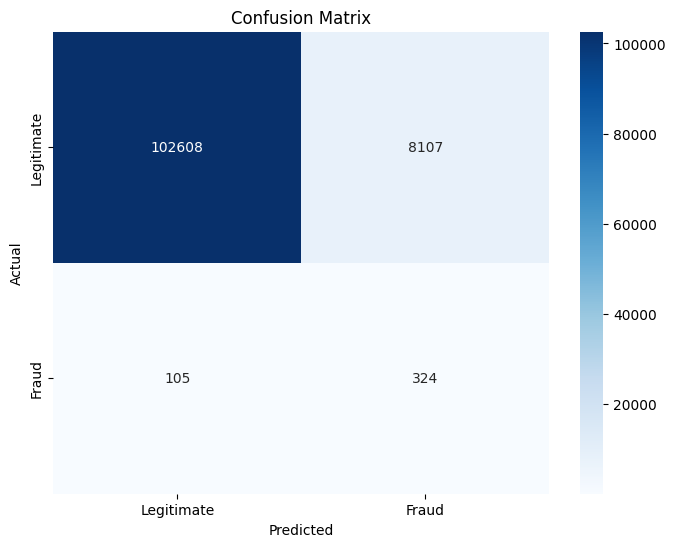

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, 
                                   random_state=42, 
                                   n_jobs=-1)
rf_model.fit(X_train_scaled, y_train_resampled)

print("Random Forest trained successfully")

Random Forest trained successfully


Random Forest Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.40      0.75      0.52       429

    accuracy                           0.99    111144
   macro avg       0.70      0.87      0.76    111144
weighted avg       1.00      0.99      1.00    111144



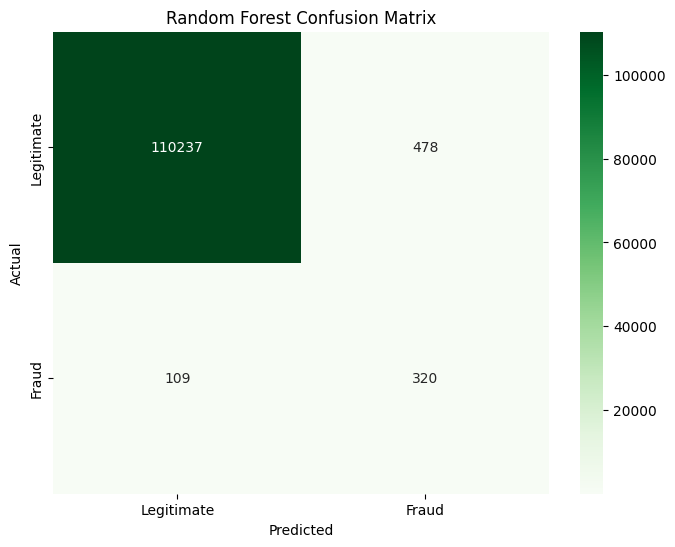

In [21]:
y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Model Comparison
Random Forest significantly outperforms Logistic Regression:
- Precision improved 10x (4% to 40%)
- Similar fraud recall (76% vs 75%)
- Overall accuracy improved (93% to 99%)
- Random Forest better handles complex fraud patterns
- Selected Random Forest as final model

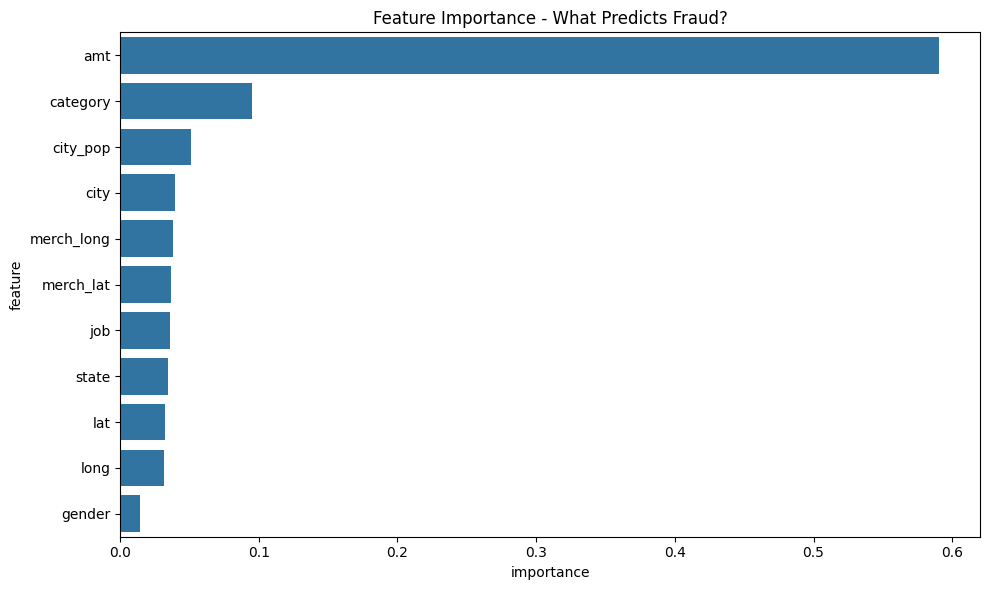

       feature  importance
1          amt    0.590531
0     category    0.095242
7     city_pop    0.051241
3         city    0.039461
10  merch_long    0.038011
9    merch_lat    0.036660
8          job    0.036019
4        state    0.034212
5          lat    0.032600
6         long    0.031663
2       gender    0.014361


In [22]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Feature Importance - What Predicts Fraud?')
plt.tight_layout()
plt.show()

print(feature_importance)

## Feature Importance Findings
- Transaction amount is strongest fraud predictor (59% importance)
  confirming fraudulent transactions average $528 vs $67 legitimate
- Merchant category second most important (9.5%)
  consistent with online categories showing higher fraud rates
- Gender least important (1.4%) confirming earlier EDA finding
- Location features (city, lat, long) contribute moderately

In [23]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, 
                           random_state=42,
                           eval_metric='logloss',
                           n_jobs=-1)

xgb_model.fit(X_train_scaled, y_train_resampled)

print("XGBoost trained successfully")

XGBoost trained successfully


XGBoost Results:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    110715
           1       0.16      0.89      0.27       429

    accuracy                           0.98    111144
   macro avg       0.58      0.93      0.63    111144
weighted avg       1.00      0.98      0.99    111144



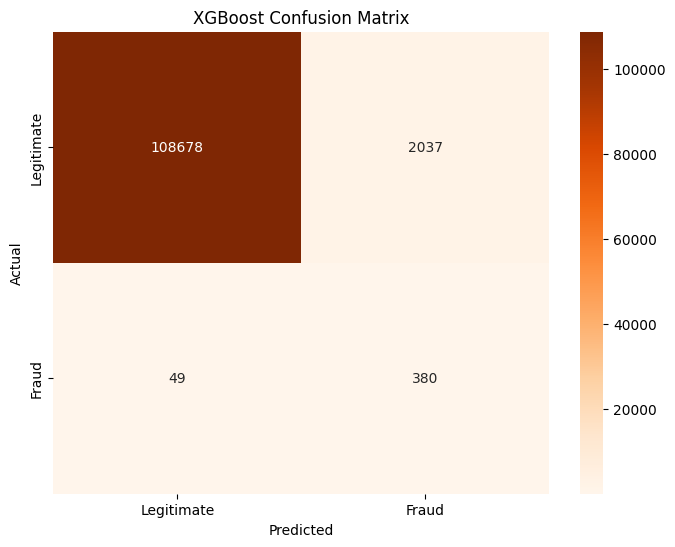

In [24]:
y_pred_xgb = xgb_model.predict(X_test_scaled)

print("XGBoost Results:")
print(classification_report(y_test, y_pred_xgb))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8,6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Final Model Comparison
## Comparing the three models

I tried three different approaches to see which worked best 
for catching fraud.

Logistic Regression was my starting point - simple and fast 
but struggled badly. It caught 76% of fraud but flagged way 
too many innocent transactions (only 4% precision). Not 
practical for a real bank.

Random Forest was much better. Precision jumped to 40% while 
still catching 75% of fraud. If I was building this for a 
premium bank that cares about not blocking good customers - 
this is the one I'd pick.

XGBoost caught the most fraud at 89% but at the cost of more 
false alarms (16% precision). If I was building this for a 
startup that wants to catch every possible fraud case and 
deal with complaints later - this fits better.

The honest answer is there's no single best model here. 
It depends entirely on what the business cares about more - 
catching fraud or protecting customer experience.

## Key Finding 3 — Fraud by Category
Online transaction categories (shopping_net, misc_net, grocery_net) 
show significantly higher fraud rates than in-person categories.
shopping_net has highest fraud rate at 1.2%.
This suggests transaction channel is a key fraud risk indicator.

## Key Finding 2 — Data Quality
No missing values across all 23 columns.
No data cleaning required — can proceed directly to analysis.

## Key Finding 1 — Class Imbalance
Dataset contains 555,719 transactions with only 0.38% fraud cases.
Severe class imbalance requires specialized handling — standard accuracy
is misleading here. Will use precision/recall and SMOTE to handle this.
